# Setup

In [1]:
from pprint import pprint
import os
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from transformers import set_seed
from transformers.utils import logging

# Device.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
use_bf16 = (device.type == 'cuda') and (torch.cuda.is_bf16_supported())

# Seed.
seed = 42
set_seed(seed)

# Suppress loggings.
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
logging.set_verbosity_error()
logging.disable_progress_bar()

c:\Users\yana\Desktop\ai-summary\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0914 16:52:57.121000 22184 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


# 1. Dataset

## Load

In [2]:
from datasets import load_dataset, DatasetDict

# Load.
data = load_dataset('stanfordnlp/imdb')

# Train-val-test split.
split = data['train'].train_test_split(
    test_size=0.2,
    stratify_by_column='label',
    seed=seed,
)

ds = DatasetDict({
    'train': split['train'],
    'val': split['test'],
    'test': data['test'],
})

## `max_length`

In [3]:
from transformers import AutoTokenizer

model_name = 'distilbert/distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

n_samples = 1_000
ds_sample = ds['train'].select(range(n_samples))

def tokenize_sample(sample):
    return tokenizer(
        sample['text'],
    )

tokenized_samples = ds_sample.map(tokenize_sample, batched=True, remove_columns=['text'])

len_tokens = pd.Series([len(tokens) for tokens in tokenized_samples['input_ids']])
percentiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
print(len_tokens.describe(percentiles=percentiles))

max_tokens = 512    # about 75% ~ 90%.

count    1000.000000
mean      309.516000
std       224.742744
min        13.000000
25%       165.750000
50%       234.000000
75%       375.750000
90%       612.100000
95%       779.050000
99%      1147.410000
max      1509.000000
dtype: float64


## Tokenize

- Skip `padding` in `tokenizer` -> `DataCollator` will do it later.

In [4]:
def tokenize(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_tokens=max_tokens,
    )

tokenized = ds.map(tokenize, batched=True, remove_columns=['text'])
tokenized = tokenized.rename_column('label', 'labels')    # for hugging face convention.

## Data Collator

In [5]:
from transformers import DataCollatorWithPadding

collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 2. Head-only Fine-Tuning

- aka linear probing

## model_init

In [6]:
from transformers import AutoModelForSequenceClassification

# Init.
def model_init(trial=None):
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,     # same name as tokenizer.
        num_labels=2,   # pos / neg.
    ).to(device)

    # Freeze.
    for name, param in model.distilbert.named_parameters():    # freeze only backbone.
        param.requires_grad = False

    return model

model = model_init()

n_params = sum(
    param.numel()
    for param in model.parameters()
)
n_trainable = sum(
    param.numel()
    for param in model.parameters()
    if param.requires_grad
)
print(
    f"n_trainable / n_params = {n_trainable:,} / {n_params:,} "
    f"({n_trainable / n_params:.2f} %)"
)

n_trainable / n_params = 592,130 / 66,955,010 (0.01 %)


## compute_metrics

In [7]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)

    accuracy = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)

    return {
        'accuracy': accuracy,
        'f1': f1,
    }

def compute_objective(metrics):
    return metrics['eval_f1']

## training_args

- Weight decay
  - A regularization method that discourages weights from becoming unnecessarily large.
  - $w \leftarrow w - \eta \nabla L - \eta \lambda w$
    - $\eta$ = learning rate.
    - $\lambda$ = weight decay strength.
- Gradient clipping
  - Clipping L2-norm of the gradient under fixed value.
  - Prevents unusually large updates from destabilizing training.
- bf16
  - Less memory, faster training.
  - Usually stable enough for transformers fine-tuning.
  - `bf16=True` doesn't mean that every params become bf16. Some operations/state stay in higher precision if needed.

In [8]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='../tmp/outputs/imdb_frozen',
    num_train_epochs=2,

    # Learning rate.
    learning_rate=3e-4,     # relatively large for head-only tuning.
    lr_scheduler_type='linear',
    warmup_steps=0.1,       # first 10% steps: 0 -> lr, remaining: lr -> 0.

    # Optimizer.
    weight_decay=1e-2,      # slightly decrease weights per update.
    max_grad_norm=1.0,      # clipping L2-norm of the gradient.

    # bf16.
    bf16=use_bf16,          # use bf16 instead of fp16. 
    
    # Batch size.
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,

    # Checkpoint.
    eval_strategy='epoch',      # run validation after every epoch.
    save_strategy='epoch',      # save a checkpoint.
    logging_strategy='steps',   # report training loss.
    logging_steps=100,          # log training loss every 100 steps.
    save_total_limit=2,         # keep only a small number of checkpoints.

    # Best model.
    load_best_model_at_end=True,    # restore the best model, instead keeping the last one.
    metric_for_best_model='f1',
    greater_is_better=True,

    # Progress.
    disable_tqdm=False,     # make sure tqdm is shown.
)

## trainer

In [9]:
from transformers import Trainer, EarlyStoppingCallback

early_stopping = EarlyStoppingCallback(
    early_stopping_patience=2,      # tolerate up to 2 consecutives without improvements > threshold.
    early_stopping_threshold=1e-3,  # should improve at least this value.
)

trainer = Trainer(
    model_init=model_init,
    args=training_args,
    callbacks=[early_stopping],

    train_dataset=tokenized['train'],
    eval_dataset=tokenized['val'],

    data_collator=collator,
    
    compute_metrics=compute_metrics,

    processing_class=tokenizer,     # saved together with model.
)

## hp_space

In [10]:
def hp_space(trial):
    learning_rate = trial.suggest_float('learning_rate', 1e-6, 5e-5, log=True)  # search by log scale.
    warmup_steps = trial.suggest_float('warmup_steps', 0.0, 0.2)
    weight_decay = trial.suggest_float('weight_decay', 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_categorical('per_device_train_batch_size', [16, 32, 64])

    return {
        'learning_rate': learning_rate,
        'weight_decay': weight_decay,
        'warmup_steps': warmup_steps,
        'per_device_train_batch_size': batch_size,
    }

## sampler / pruner

In [11]:
# Sampler: uses prev results to choose the next params more wisely.
sampler = optuna.samplers.TPESampler(seed=seed)

# Pruner: early stopping for trials, at least 5 trials without pruning.
pruner = optuna.pruners.MedianPruner(n_startup_trials=5)

## HPO

In [12]:
best_run = trainer.hyperparameter_search(
    direction='maximize',
    backend='optuna',
    hp_space=hp_space,
    compute_objective=compute_objective,
    n_trials=1,
    sampler=sampler,
    pruner=pruner,
    n_jobs=1,               # run one trial at a time, since we use one GPU for now.
    gc_after_trial=True,    # garbage collection after each trial.
)
best_hp = best_run.hyperparameters
pprint(best_hp)

[I 2026-09-14 16:53:05,809] A new study created in memory with name: no-name-632f8f2f-c671-4e58-b087-5045b7302f9e


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.650255,0.642414,0.797200,0.791872
2,0.624927,0.618218,0.798200,0.798643


[I 2026-09-14 16:53:55,024] Trial 0 finished with value: 0.7986429854320495 and parameters: {'learning_rate': 4.328450221293881e-06, 'warmup_steps': 0.19014286128198324, 'weight_decay': 0.015702970884055395, 'per_device_train_batch_size': 16}. Best is trial 0 with value: 0.7986429854320495.


{'learning_rate': 4.328450221293881e-06,
 'per_device_train_batch_size': 16,
 'warmup_steps': 0.19014286128198324,
 'weight_decay': 0.015702970884055395}


## Training

In [13]:
import copy

path = '../tmp/final_model'

# Model.
final_model = model_init(None)

# Training args.
final_training_args = copy.deepcopy(training_args)

for key, value in best_run.hyperparameters.items():
    setattr(final_training_args, key, value)

final_training_args.output_dir = path

# Trainer.
final_trainer = Trainer(
    model=final_model,      # not model_init for final training.
    args=final_training_args,

    train_dataset=tokenized['train'],
    eval_dataset=tokenized['val'],

    processing_class=tokenizer,
    data_collator=collator,

    compute_metrics=compute_metrics,
)

# Train.
final_trainer.train()

# Validation.
eval_results = final_trainer.evaluate()
print("Final evaluation:")
pprint(eval_results)

# Save.
final_trainer.save_model(path)
tokenizer.save_pretrained(path)

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.651235,0.642326,0.799400,0.794678
2,0.624791,0.618395,0.798800,0.799442


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.624791,0.618395,2,0.798800,0.799442


Final evaluation:
{'eval_accuracy': 0.7988,
 'eval_f1': 0.7994417862838915,
 'eval_loss': 0.6183949112892151}


('../tmp/final_model\\tokenizer_config.json',
 '../tmp/final_model\\tokenizer.json')

## Learning Curve

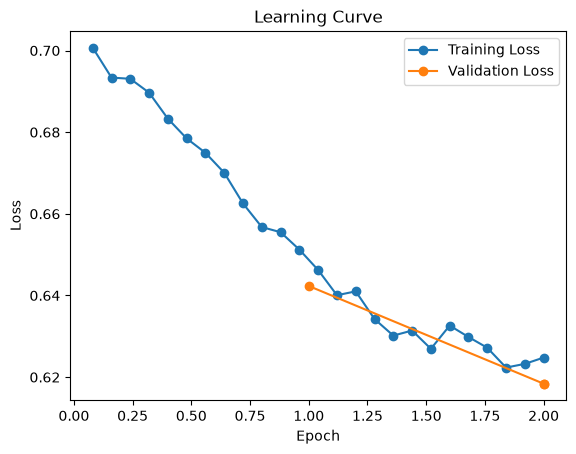

In [14]:
# Extract.
log_history = final_trainer.state.log_history

train_epoch, train_loss = [], []
val_epoch, val_loss = [], []

for log in log_history:
    if "loss" in log:
        train_epoch.append(log["epoch"])
        train_loss.append(log["loss"])

    if "eval_loss" in log:
        val_epoch.append(log["epoch"])
        val_loss.append(log["eval_loss"])

# Plot.
plt.plot(
    train_epoch,
    train_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    val_epoch,
    val_loss,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve")

plt.legend()
plt.show()

# 3. Full Fine-Tuning

## Quantization

### Theories

#### Basic

- Continuous values -> much smaller discrete representation.
  - e.g. [0.07, 0.26, 0.48] -> [0.0, 0.25, 0.5]
- $q = round(\frac{x}{s}) + z$
  - $x$ = original floating-point value
  - $q$ = stored quantized integer
  - $s$ = scale = $\frac{x_{max} - x_{min}}{q_{max} - q_{min}}$
    - e.g. range = [-1, 1], 4-bit unsigned ints = [0, 15] -> $s = \frac{1 - (-1)}{15 - 0} \approx 0.1333$
  - $z$ = zero-point = which quantized int corresponds to real value 0?
    - e.g. [-1, 1] -> [0, 15] -> $z \approx 8$
- $\hat{x} = s(q - z)$

#### Symmetric vs Asymmetric

```markdown
[-1 ---------------- 0 ---------------- +1]
      8-ish bins          8-ish bins
- Symmetric quantization
  - Values are centered around 0.
  - $z = 0 \rightarrow q = round(\frac{x}{s})$
  - Real 0 maps directly to integer 0.
  - Very common for neural-network weights.

[-0.2 ------------------------------ +1.0]
        all bins used over this range
- Asymmetric quantization
  - e.g. values in [-0.2, 1.0] -> [-1.0, -0.2] will be wasted in a symmetric quantization.
  - Can be useful for activations.
```

#### Level of Quantization

- Weight quantization: $W_{fp16} \rightarrow W_{int4}$
- Activation quantization
  - Hidden states
  - Attention outputs
  - FFN activations
  - ...
- W8A8 = Weights into int8 / activations into int8
- W4A16 = Weights into int4 / activations into int16 = closer to QLoRA style.

#### PTQ vs QAT

- PTQ: Post-Training Quantization
  - Train normally -> quantize weights.
  - Pros: simple/cheap -> very common for deployment/inference.
  - Cons: a model never learns quantization error -> probably lower performance.
- QAT: Quantization-Aware Training
  - During training, simulate the effects of quantization.
  - Let the model adapt to the quantization error during training.
  - Preserve accuracy better, but more complicated and expensive.
  - STE: straight-through estimator
    - Forward behaves like quantization.
    - Backward uses an approximate gradient.

#### NF4

- NormalFloat 4-bit: introduced with QLoRA.
- Better representation than int4 for neural network's weights.
  - int4 → 16 uniformly distributed integer-like levels.
  - nf4 → 16 non-uniform levels for a normal distribution.

#### QLoRA

- Quantization + LoRA
- $y = W_{\text{dequant(BF16)}}x_{\text{BF16}} + \frac{\alpha}{r}B_{\text{BF16}}A_{\text{BF16}}x_{\text{BF16}}$
- Store base weights as 4-bit -> temporarily dequantize to BF16/FP16 for computation.
- Base weights stay frozen, and only LoRA parameters are updated.

### Usage

In [15]:
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments,
    BitsAndBytesConfig,
)
from peft import prepare_model_for_kbit_training

# bnb config.
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# Model.
base_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    quantization_config=bnb_config,
)
quantized_model = prepare_model_for_kbit_training(
    base_model,
    use_gradient_checkpointing=True,    # stores fewer intermediate activations -> reduce VRAM.
    gradient_checkpointing_kwargs=None,
)

## PEFT

### LoRA

- $W' = W + \Delta W$, where $W \in R^{d_{out} \times d_{in}}$
- $\Delta W = BA$, where $B \in R^{d_{out} \times r}, A \in R^{r \times d_{in}}, r \ll d_{out}, d_{in}$
- $y = Wx + \frac{\alpha}{r}BAx$, where $r = \text{rank}, \alpha = \text{lora alpha}$.

In [16]:
from peft import LoraConfig, TaskType, get_peft_model

# Layer names to apply LoRA.
print("Named modules to apply lora:")
for name, module in base_model.named_modules():
    if isinstance(module, nn.Linear):
        print(f"{name}: {module.in_features} -> {module.out_features}")

# LoRA.
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,     # sequence classification, i.e. IMDb.
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=['q_lin', 'v_lin'],
    bias='none',    # if 'none', don't train the biases of original layers.
)
model = get_peft_model(quantized_model, lora_config)
model.print_trainable_parameters()

# Memory usage.
memory_gb = model.get_memory_footprint() / 1024**3
print('Model memory footprint:', f'{memory_gb:.3f} GB')

# Trainable modules.
print("Trainable modules of lora:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

# Number of lora params.
lora_params = 0
for name, param in model.named_parameters():
    if 'lora_' in name:
        lora_params += param.numel()
print(f"Lora params: {lora_params:,}")  # n_params added by lora.

Named modules to apply lora:
distilbert.transformer.layer.0.attention.q_lin: 768 -> 768
distilbert.transformer.layer.0.attention.k_lin: 768 -> 768
distilbert.transformer.layer.0.attention.v_lin: 768 -> 768
distilbert.transformer.layer.0.attention.out_lin: 768 -> 768
distilbert.transformer.layer.0.ffn.lin1: 768 -> 3072
distilbert.transformer.layer.0.ffn.lin2: 3072 -> 768
distilbert.transformer.layer.1.attention.q_lin: 768 -> 768
distilbert.transformer.layer.1.attention.k_lin: 768 -> 768
distilbert.transformer.layer.1.attention.v_lin: 768 -> 768
distilbert.transformer.layer.1.attention.out_lin: 768 -> 768
distilbert.transformer.layer.1.ffn.lin1: 768 -> 3072
distilbert.transformer.layer.1.ffn.lin2: 3072 -> 768
distilbert.transformer.layer.2.attention.q_lin: 768 -> 768
distilbert.transformer.layer.2.attention.k_lin: 768 -> 768
distilbert.transformer.layer.2.attention.v_lin: 768 -> 768
distilbert.transformer.layer.2.attention.out_lin: 768 -> 768
distilbert.transformer.layer.2.ffn.lin1: 768 

### Other methods

- Bottleneck adapters
  - Adds a small trainable network inside a transformer block.
  - vs LoRA: adds a low-rank update to an existing weight matrix.
- Prompt tuning
  - A transformer is frozen.
  - Hard prompt: adds readable tokens manually, e.g. "Classify the sentiment of this text: ".
  - Soft prompt: adds some additional embedding vectors before original embedding vectors.
- Prefix tuning
  - Inserts some learned continuous representations into the transformer's **attention** layers.
  - K = [prefix_K; normal_K]
  - V = [prefix_V; normal_V]
- $IA^3$
  - Instead of adding matrices $A, B$ like LoRA, it learns small scaling vectors -> even fewer parameters.
  - Hidden $h = [h_1, h_2, ..., h_d]$
  - Scaling vectors $l = [l_1, l_2, ..., l_d]$
  - Final hidden $h' = h \odot l$, $\odot$ = element-wise multiplication.
- AdaLoRA
  - Dynamically allocate $r$ according to the importance of each matrix.
- DoRA
  - Weight-Decomposed LoRA.
  - Decompose $W$ into magnitude and direction, i.e. $w = m \cdot u$ where $m = ||w||_2, u = \frac{w}{||w||_2}$
  - Magnitude -> learn directly with a small trainable parameter
  - Direction -> adapt using LoRA
  - `LoraConfig(use_dora=True)`

## model_init

In [17]:
# bnb config.
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    llm_int8_skip_modules=[     # do not quantize the classification heads.
        'pre_classifier',
        'classifier',
    ]
)

# Lora config.
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,     # sequence classification, i.e. IMDb.
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=['q_lin', 'v_lin'],
    bias='none',    # if 'none', don't train the biases of original layers.
)

# Model.
def model_init(trial=None):
    base_model = AutoModelForSequenceClassification.from_pretrained(
        model_name,     # same name as tokenizer.
        num_labels=2,   # pos / neg.
        quantization_config=bnb_config,
    )

    quantized_model = prepare_model_for_kbit_training(
        base_model,
        use_gradient_checkpointing=True,    # stores fewer intermediate activations -> reduce VRAM.
        gradient_checkpointing_kwargs=None,
    )

    model = get_peft_model(quantized_model, lora_config)

    return model

## training_args

In [18]:
# Training args.
training_args.optim = 'paged_adamw_32bit'   # moving optimizer-state memory btw GPU <-> CPU, to avoid OOM.

## trainer

In [19]:
from transformers import Trainer, EarlyStoppingCallback

early_stopping = EarlyStoppingCallback(
    early_stopping_patience=2,      # tolerate up to 2 consecutives without improvements > threshold.
    early_stopping_threshold=1e-3,  # should improve at least this value.
)

trainer = Trainer(
    model_init=model_init,
    args=training_args,
    callbacks=[early_stopping],

    train_dataset=tokenized['train'],
    eval_dataset=tokenized['val'],

    data_collator=collator,
    
    compute_metrics=compute_metrics,

    processing_class=tokenizer,     # saved together with model.
)

## HPO

In [20]:
# HPO.
best_run = trainer.hyperparameter_search(
    direction='maximize',
    backend='optuna',
    hp_space=hp_space,
    compute_objective=compute_objective,
    n_trials=1,
    sampler=sampler,
    pruner=pruner,
    n_jobs=1,               # run one trial at a time, since we use one GPU for now.
    gc_after_trial=True,    # garbage collection after each trial.
)
best_hp = best_run.hyperparameters
pprint(best_hp)

[I 2026-09-14 16:54:49,099] A new study created in memory with name: no-name-8ff5c69f-2d1f-4b89-96ea-cbdfb48759b8
c:\Users\yana\Desktop\ai-summary\.venv\Lib\site-packages\torch\_dynamo\eval_frame.py:1298: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.690105,0.688304,0.516200,0.068541
2,0.687316,0.685451,0.554200,0.212646


c:\Users\yana\Desktop\ai-summary\.venv\Lib\site-packages\torch\_dynamo\eval_frame.py:1298: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
[I 2026-09-14 16:56:52,599] Trial 0 finished with value: 0.21264570823030732 and parameters: {'learning_rate': 1.255111517297383e-06, 'warmup_steps': 0.17323522915498704, 'weight_decay': 0.006358358856676255, 'per_device_train_batch_size': 64}. Best is trial 0 with value: 0.21264570823030732.


{'learning_rate': 1.255111517297383e-06,
 'per_device_train_batch_size': 64,
 'warmup_steps': 0.17323522915498704,
 'weight_decay': 0.006358358856676255}


## Training

In [21]:
# Model.
final_model = model_init(None)

# Training args.
final_training_args = copy.deepcopy(training_args)

for key, value in best_run.hyperparameters.items():
    setattr(final_training_args, key, value)

final_training_args.output_dir = path

# Trainer.
final_trainer = Trainer(
    model=final_model,      # not model_init for final training.
    args=final_training_args,

    train_dataset=tokenized['train'],
    eval_dataset=tokenized['val'],

    processing_class=tokenizer,
    data_collator=collator,

    compute_metrics=compute_metrics,
)

# Train.
final_trainer.train()

# Validation.
eval_results = final_trainer.evaluate()
print("Final evaluation:")
pprint(eval_results)

# Save.
final_trainer.save_model(path)
tokenizer.save_pretrained(path)

c:\Users\yana\Desktop\ai-summary\.venv\Lib\site-packages\torch\_dynamo\eval_frame.py:1298: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.692702,0.689835,0.500800,0.666578
2,0.687108,0.686635,0.551800,0.683787


c:\Users\yana\Desktop\ai-summary\.venv\Lib\site-packages\torch\_dynamo\eval_frame.py:1298: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.687108,0.686635,2,0.551800,0.683787


Final evaluation:
{'eval_accuracy': 0.5518,
 'eval_f1': 0.6837872160293496,
 'eval_loss': 0.6866351366043091}


('../tmp/final_model\\tokenizer_config.json',
 '../tmp/final_model\\tokenizer.json')

## Learning Curve

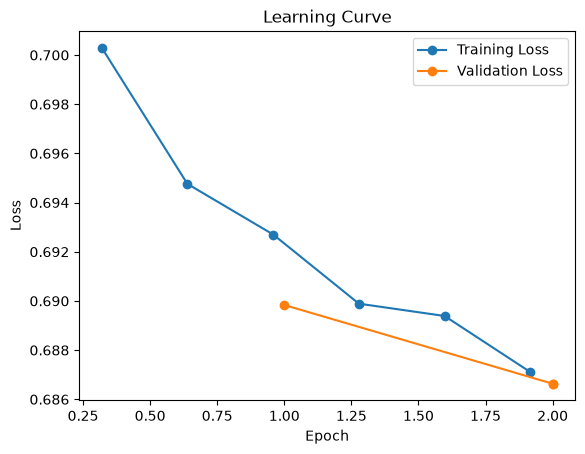

In [22]:
# Extract.
log_history = final_trainer.state.log_history

train_epoch, train_loss = [], []
val_epoch, val_loss = [], []

for log in log_history:
    if "loss" in log:
        train_epoch.append(log["epoch"])
        train_loss.append(log["loss"])

    if "eval_loss" in log:
        val_epoch.append(log["epoch"])
        val_loss.append(log["eval_loss"])

# Plot.
plt.plot(
    train_epoch,
    train_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    val_epoch,
    val_loss,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve")

plt.legend()
plt.show()

# 4. SFT: Supervised Fine-Tuning

- Supervised Fine-Tuning.
  - Base model -> SFT -> Instruction-tuned / chat model
  - e.g. Qwen base -> Qwen-Instruct.
- Full-sequence loss
  - Calculates the loss from the whole sequence, i.e. [system], [user], [assistant], like causal language models.
  - Learn the whole training sequence distribution.
- Response-only loss masking
  - aka assistant-only or completion-only loss masking.
  - Specifically optimize desired assistant generations.
  - CLM: predicts a next token for the entire texts.
  - SFT: predicts only a desired response -> masks the prompt tokens' labels.
- Roles
  - Inserted as a special token, model-specifically defined.
  - System: high-level behavior / policy / persona / task setup.
  - User: request or input.
  - Assistant: desired model response.

> Note) SFT also packs multiple samples, but each conversation should be preserved intact, not truncated.

## Dataset

In [23]:
from datasets import load_dataset, DatasetDict

# Load.
data_name = 'HuggingFaceH4/ultrachat_200k'
data = load_dataset(data_name)
ds = DatasetDict({
    'train': data['train_sft'],
    'valid': data['test_sft'],
})
pprint(ds['train']['messages'][1][:2])

# Samples.
n_samples = 1_000
train_ds = ds['train'].select(range(n_samples)).select_columns(['messages'])
valid_ds = ds['valid'].select(range(n_samples)).select_columns(['messages'])

[{'content': 'Which famous landmarks should I visit in London, beyond the '
             'usual ones?',
  'role': 'user'},
 {'content': '1. Leadenhall Market - a beautiful indoor market with stunning '
             'Victorian architecture, also used as a filming location in the '
             'Harry Potter films.\n'
             '\n'
             '2. St. Dunstan in the East - a ruined church in the middle of '
             'the city that has been turned into a beautiful public garden.\n'
             '\n'
             '3. The Monument - a 202-foot-tall column commemorating the Great '
             'Fire of London, with a staircase leading to a viewing platform '
             'offering great views of the city.\n'
             '\n'
             '4. The Camden Town Markets - an eclectic collection of markets '
             'offering food, fashion, and vintage items, plus live music and '
             'street performers.\n'
             '\n'
             "5. Novelist's House - the former h

## Template

In [24]:
from transformers import AutoTokenizer

# Tokenizer.
model_name = 'Qwen/Qwen2.5-0.5B'
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Apply chat template.
text = tokenizer.apply_chat_template(       # converts into the template that a tokenizer/model expects.
    train_ds[1]['messages'],
    tokenize=False,
    add_generation_prompt=False,    # if True, add a special token for the beginning of assistance's reply -> not needed for training.
)

pprint(text)

('<|im_start|>system\n'
 'You are a helpful assistant.<|im_end|>\n'
 '<|im_start|>user\n'
 'Which famous landmarks should I visit in London, beyond the usual '
 'ones?<|im_end|>\n'
 '<|im_start|>assistant\n'
 '1. Leadenhall Market - a beautiful indoor market with stunning Victorian '
 'architecture, also used as a filming location in the Harry Potter films.\n'
 '\n'
 '2. St. Dunstan in the East - a ruined church in the middle of the city that '
 'has been turned into a beautiful public garden.\n'
 '\n'
 '3. The Monument - a 202-foot-tall column commemorating the Great Fire of '
 'London, with a staircase leading to a viewing platform offering great views '
 'of the city.\n'
 '\n'
 '4. The Camden Town Markets - an eclectic collection of markets offering '
 'food, fashion, and vintage items, plus live music and street performers.\n'
 '\n'
 "5. Novelist's House - the former home of Charles Dickens, now a museum "
 'dedicated to his life and works.\n'
 '\n'
 '6. The Old Operating Theatre -

## Training

- `%pip install -u trl`
  - `trl`: transformers reinforcement learning.

In [ ]:
from transformers import AutoModelForCausalLM
from trl import SFTConfig, SFTTrainer
from pprint import pprint


# Model.
model = AutoModelForCausalLM.from_pretrained(model_name)

# Training arguments.
sft_args = SFTConfig(
    output_dir='outputs/qwen_sft',

    max_length=512,
    assistant_only_loss=True,   # ignores the labels for user tokens, i.e. -100.
    packing=True,               # allow multiple examples into one sequence.
    packing_strategy='bfd',     # keep each example intact; do not split it across packed sequences.

    chat_template_path='Qwen/Qwen2.5-0.5B-Instruct',
    eos_token='<|im_end|>',

    learning_rate=1e-4,
    optim='paged_adamw_32bit',
    bf16=use_bf16,

    num_train_epochs=2,
    per_device_train_batch_size=8,

    logging_strategy='epoch',
    report_to=[],
)

# Trainer.
sft_trainer = SFTTrainer(
    model=model,
    args=sft_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    processing_class=tokenizer,
)

# Remaining parts are same as typical fine-tuning.

[RANK 0] Padding-free training is enabled, but the attention implementation is not set to a supported Flash Attention variant. Padding-free training flattens batches into a single sequence, and only the following implementations are known to reliably support this: flash_attention_2, flash_attention_3, kernels-community/flash-attn2, kernels-community/flash-attn3, kernels-community/vllm-flash-attn3. Using other implementations may lead to unexpected behavior. To ensure compatibility, set `attn_implementation` in the model configuration to one of these supported options or verify that your attention mechanism can handle flattened sequences.
[RANK 0] You are using packing, but the attention implementation is not set to a supported Flash Attention variant. Packing gathers multiple samples into a single sequence, and only the following implementations are known to reliably support this: flash_attention_2, flash_attention_3, kernels-community/flash-attn2, kernels-community/flash-attn3, kernel

# 5. DPO: Direct Preference Optimization

- Direct Preference Optimization.
- Give two answers -> learn to prefer one over the other.

```markdown
{
    'prompt': 'Explain gradient descent simply.',
    'chosen': 'Gradient descent updates parameters in the direction that reduces the loss.',
    'rejected': 'Gradient descent randomly changes parameters until the model improves.',
}
```

- Reference model
  - Policy model: a target model to train.
  - Reference model: a frozen model, usually the SFT model before DPO training.
  - Prefer the chosen response **more than the original model did**, without drifting arbitrarily far from the original behavior.
- KL divergence
  - Kullback-Leibler divergence.
  - It measures how different one probability distribution is from another.
  - $D_{\mathrm{KL}}(\pi_\theta \,\|\, \pi_{\mathrm{ref}})$

- Loss, $L_{\mathrm{DPO}}=-\log \sigma\left(\beta\left[\log\frac{\pi_\theta(y_w \mid x)}{\pi_{\mathrm{ref}}(y_w \mid x)}-\log\frac{\pi_\theta(y_l \mid x)}{\pi_{\mathrm{ref}}(y_l \mid x)}\right]\right)$
  - $x$: prompt
  - $y_w$: chosen / preferred response
  - $y_l$: rejected / less-preferred response
  - $\pi_\theta$: trainable policy model
  - $\pi_{\mathrm{ref}}$: frozen reference model
  - $\sigma$: sigmoid function
  - $\beta$: controls how strongly the policy stays anchored to the reference model
    - larger β  → stronger anchoring to reference / more conservative change
    - smaller β → allows greater deviation from reference
- RLHF
  - Reinforcement learning from human feedback.
  - Train SFT model -> generate 2 answers per prompt -> human labels the preference.
  - Train a reward model: scores higher for human-preferred answer.
  - PPO, Proximal Policy Optimization
    - computes how the policy (LLM) should change.
- DPO vs RLHF
  - DPO: preferences -> directly optimize LLM
  - RLHF: preferences -> reward model -> PPO -> LLM
- Useful metrics to monitor during training
  - `loss` → DPO loss; lower is generally better.
  - `rewards/chosen` → Implicit DPO reward for chosen responses.
  - `rewards/rejected` → Implicit DPO reward for rejected responses.
  - `rewards/margins` → Chosen reward − rejected reward; larger positive values mean better separation.
  - `rewards/accuracies` → Fraction where chosen reward > rejected reward; > 0.5 means preferred answers win more often.

- Other methods

| Method | Full Name | Data / Signal | Reference Model? | Main Idea |
|---|---|---|---|---|
| **DPO** | Direct Preference Optimization | Paired `chosen` / `rejected` responses | Yes | Directly increase preference for chosen over rejected relative to a frozen reference model. |
| **KTO** | Kahneman-Tversky Optimization | Individual `good` / `bad` feedback | No paired responses required | Learn from binary desirability feedback such as thumbs-up / thumbs-down. |
| **ORPO** | Odds Ratio Preference Optimization | Paired preferences | No | Combine SFT and preference optimization in one stage; increase chosen likelihood while penalizing rejected responses. |
| **SimPO** | Simple Preference Optimization | Paired preferences | No | DPO-like reference-free optimization using average sequence log-probability and a preference margin. |
| **GRPO** | Group Relative Policy Optimization | Online generated responses + rewards | Not DPO-style | Generate multiple responses, score them, and optimize each response relative to the group; mainly an RL/post-training method. |

In [ ]:
from trl import DPOConfig, DPOTrainer
from datasets import load_dataset

# Data.
dpo_train_ds = load_dataset(
    'trl-lib/ultrafeedback_binarized',
    split='train[:10000]',
)

dpo_val_ds = load_dataset(
    'trl-lib/ultrafeedback_binarized',
    split='test[:1000]',
)

pprint(dpo_train_ds)
pprint(dpo_train_ds[0])

# Training args.
dpo_args = DPOConfig(
    output_dir='outputs/qwen_dpo',
    beta=0.1,
    learning_rate=1e-6,
    max_length=512,
    bf16=use_bf16,
    report_to=[],
)

# Trainer.
dpo_trainer = DPOTrainer(
    model=model,
    args=dpo_args,
    train_dataset=dpo_train_ds,
    eval_dataset=dpo_val_ds,
    processing_class=tokenizer,
)

# Remaining parts are same as typical fine-tuning.

Dataset({
    features: ['chosen', 'rejected', 'score_chosen', 'score_rejected'],
    num_rows: 10000
})
{'chosen': [{'content': 'Use the pygame library to write a version of the '
                        'classic game Snake, with a unique twist',
             'role': 'user'},
            {'content': "Sure, I'd be happy to help you write a version of the "
                        "classic game Snake using the pygame library! Here's a "
                        'basic outline of how we can approach this:\n'
                        '\n'
                        "1. First, we'll need to set up the game display and "
                        'create a game object that we can use to handle the '
                        "game's state.\n"
                        "2. Next, we'll create the game's grid, which will be "
                        "used to represent the game board. We'll need to "
                        'define the size of the grid and the spaces within '
                        'it.\